In [1]:
from importlib.resources import files
import pandas as pd
import numpy as np
from matplotlib import pyplot as plt
from scipy.stats import chi2_contingency

## Basic analysis

In [5]:
csv_path = "../data/echonext_metadata_100k.csv"
df = pd.read_csv(csv_path, index_col=0)
df = df[df["split"] == "train"].drop(columns=["split"])
df.shape

(72475, 37)

In [6]:
# remove echo derived features (not flags) because i will focus on predicting the flags
value_cols = [col for col in df.columns if col.endswith("value") or col.endswith("measurement")]
df = df.drop(columns=value_cols)
df.head()

,ecg_key,patient_key,age_at_ecg,sex,acquisition_year,location_setting,race_ethnicity,most_recent_ecg,ventricular_rate,atrial_rate,...,aortic_stenosis_moderate_or_greater_flag,aortic_regurgitation_moderate_or_greater_flag,mitral_regurgitation_moderate_or_greater_flag,tricuspid_regurgitation_moderate_or_greater_flag,pulmonary_regurgitation_moderate_or_greater_flag,rv_systolic_dysfunction_moderate_or_greater_flag,pericardial_effusion_moderate_large_flag,pasp_gte_45_flag,tr_max_gte_32_flag,shd_moderate_or_greater_flag
0,8520052,902618160,88,male,2014,emergency,other,1,117.0,117.0,...,0,0,0,0,0,0,0,0,0,0
1,7283576,4764241080,69,female,2019,inpatient,black,0,99.0,99.0,...,0,0,0,0,0,0,0,0,0,0
2,8769869,4214459612,22,male,2017,inpatient,white,0,86.0,86.0,...,0,0,0,0,0,0,0,1,0,1
3,6379904,6205191619,70,male,2022,emergency,hispanic,0,68.0,68.0,...,0,0,0,0,0,0,0,0,0,1
4,9619545,8380688329,54,male,2013,inpatient,other,0,90.0,93.0,...,0,0,0,0,0,1,0,0,0,1


In [7]:
df.shape

(72475, 25)

In [8]:
df.dtypes

ecg_key                                               int64
patient_key                                           int64
age_at_ecg                                            int64
sex                                                  object
acquisition_year                                      int64
location_setting                                     object
race_ethnicity                                       object
most_recent_ecg                                       int64
ventricular_rate                                    float64
atrial_rate                                         float64
pr_interval                                         float64
qrs_duration                                        float64
qt_corrected                                        float64
lvef_lte_45_flag                                      int64
lvwt_gte_13_flag                                      int64
aortic_stenosis_moderate_or_greater_flag              int64
aortic_regurgitation_moderate_or_greater

In [9]:
print(f"Unique patients: {df["patient_key"].nunique()}, mean instances per patient {df["patient_key"].value_counts().mean()}")

Unique patients: 26218, mean instances per patient 2.764322221374628


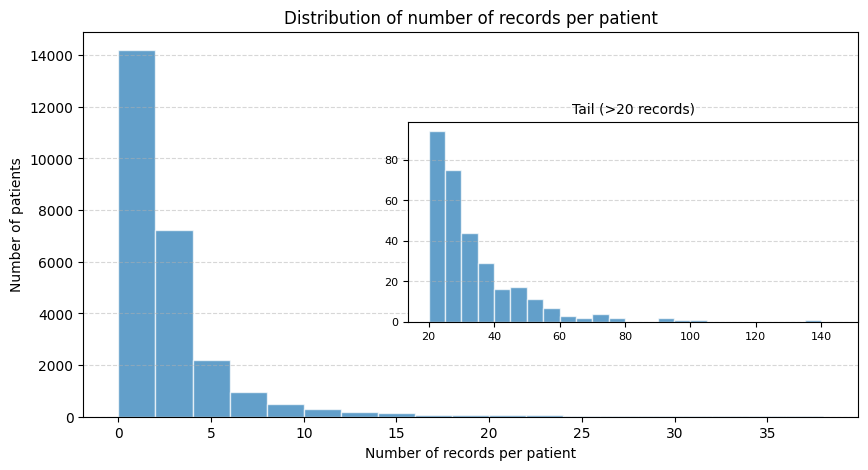

In [18]:
counts = df["patient_key"].value_counts()

fig, ax = plt.subplots(figsize=(10, 5))
ax.hist(counts, bins=range(0, 40, 2), edgecolor='white', alpha=0.7)
ax.set_xlabel("Number of records per patient")
ax.set_ylabel("Number of patients")
ax.set_title("Distribution of number of records per patient")
ax.grid(axis='y', linestyle='--', alpha=0.5)

ax_inset = fig.add_axes([0.45, 0.3, 0.45, 0.4]) 

tail = counts[counts > 20]
ax_inset.hist(tail, bins=range(20, 150, 5), edgecolor='white', alpha=0.7)

ax_inset.set_title("Tail (>20 records)", fontsize=10)
ax_inset.tick_params(axis='both', labelsize=8)
ax_inset.grid(axis='y', linestyle='--', alpha=0.5)

plt.show()

most of the patients don't have more than 10 records

In [20]:
# check for duplicates
print(f"Duplicate rows: {df.duplicated().sum()}")

Duplicate rows: 0


In [21]:
# drop ecg_key because this part of eda is focused on tabular features
df = df.drop(columns=["ecg_key"])

In [22]:
# classify features into meta, predictors and targets
features = {
    "meta": ["patient_key", "acquisition_year", "location_setting", "most_recent_ecg"],
    "predictors": {
        "categorical": ["sex", "race_ethnicity"],
        "continuous": ["ventricular_rate", "atrial_rate", "pr_interval", "qrs_duration", "qt_corrected"]
    },
    "targets": [col for col in df.columns if col.endswith("flag")]
}

## Missingness analysis

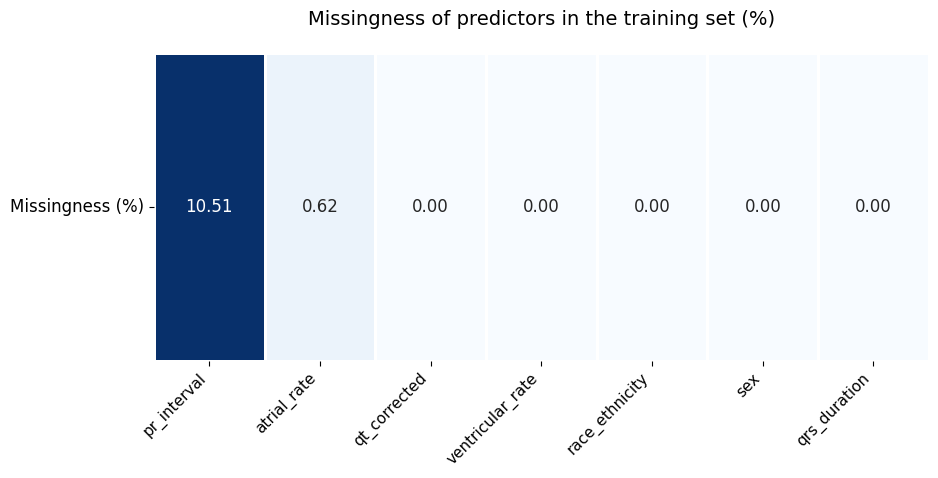

In [29]:
import seaborn as sns
predictor_cols = features["predictors"]["categorical"] + features["predictors"]["continuous"]

missing_pct = (
    df[predictor_cols]
    .isna()
    .mean()
    .mul(100)
    .sort_values(ascending=False)
    .to_frame(name="Missingness (%)")
)

plt.figure(figsize=(10, 4))

sns.heatmap(
    missing_pct.T, 
    annot=True, 
    cmap="Blues", 
    fmt=".2f", 
    cbar=False, 
    annot_kws={"size": 12},
    linewidths=1,
    linecolor='white'
)

plt.title("Missingness of predictors in the training set (%)", fontsize=14, pad=20)
plt.yticks(rotation=0,fontsize=12,)
plt.xticks(rotation=45, ha='right', fontsize=11)
plt.show()

In [30]:
# missingness of targets
df.isna()[features["targets"]].mean().mul(100).sort_values(ascending=False)

lvef_lte_45_flag                                    0.0
lvwt_gte_13_flag                                    0.0
aortic_stenosis_moderate_or_greater_flag            0.0
aortic_regurgitation_moderate_or_greater_flag       0.0
mitral_regurgitation_moderate_or_greater_flag       0.0
tricuspid_regurgitation_moderate_or_greater_flag    0.0
pulmonary_regurgitation_moderate_or_greater_flag    0.0
rv_systolic_dysfunction_moderate_or_greater_flag    0.0
pericardial_effusion_moderate_large_flag            0.0
pasp_gte_45_flag                                    0.0
tr_max_gte_32_flag                                  0.0
shd_moderate_or_greater_flag                        0.0
dtype: float64

In [31]:
# missingness of meta features
df.isna()[features["meta"]].mean().mul(100).sort_values(ascending=False)

patient_key         0.0
acquisition_year    0.0
location_setting    0.0
most_recent_ecg     0.0
dtype: float64

So we only have some missing values for pr_interval and atrial_rate.

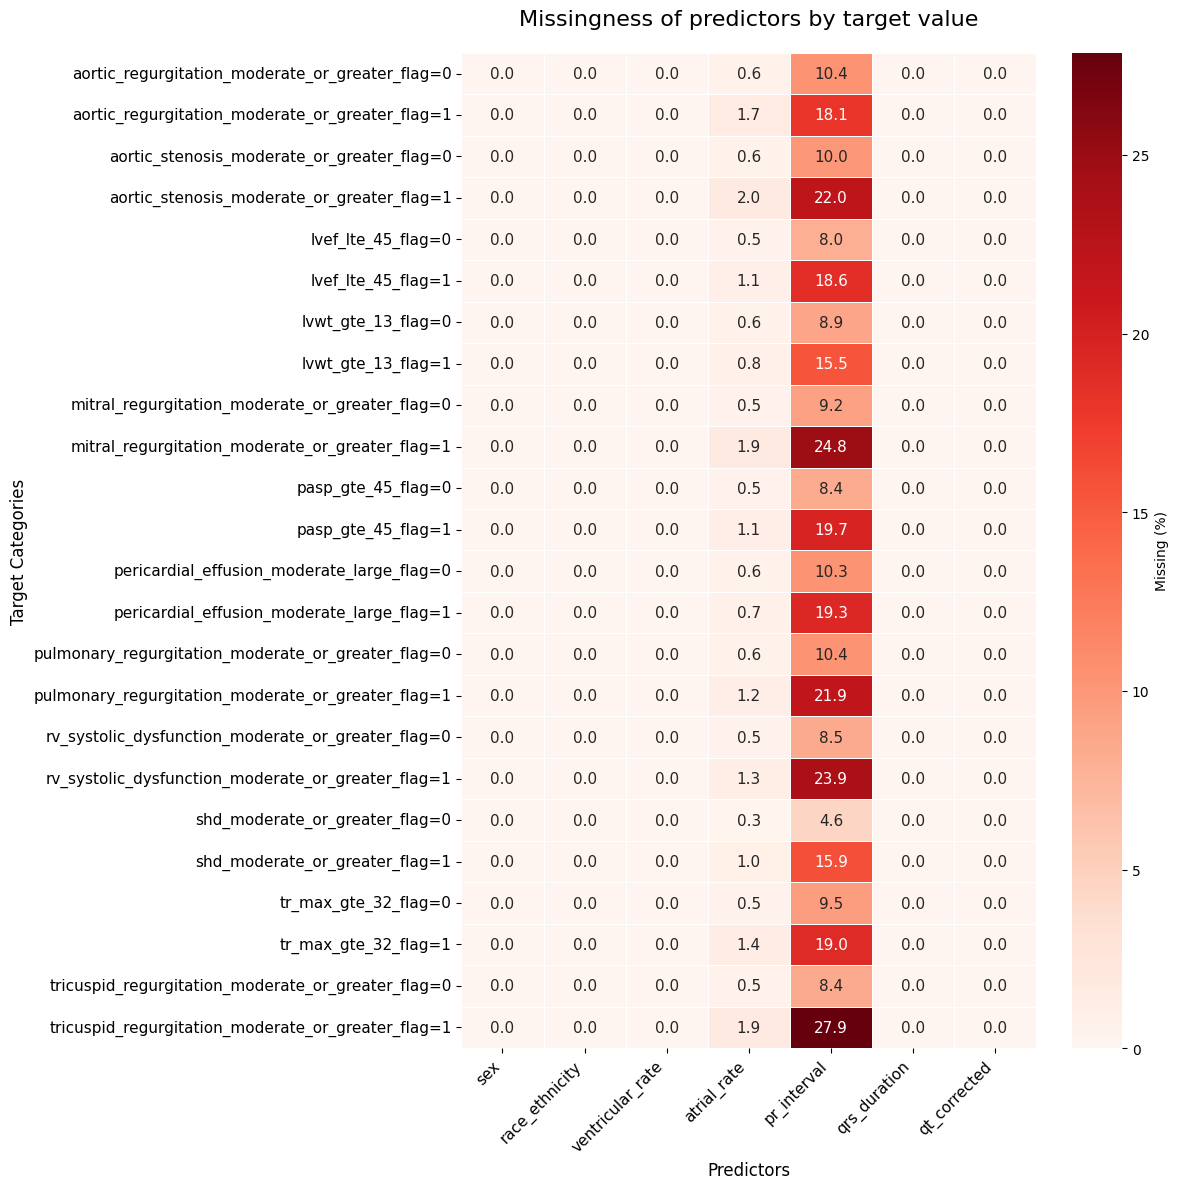

In [41]:
all_rows = []
for target in features["targets"]:
    group = df.groupby(target)[predictor_cols].apply(lambda x: x.isna().mean() * 100)
    for val, row in group.iterrows():
        all_rows.append({
            'target_name': target,
            'flag_value': int(val),
            **row.to_dict()
        })

heatmap_data = pd.DataFrame(all_rows)
heatmap_data['label'] = heatmap_data['target_name'] + '=' + heatmap_data['flag_value'].astype(str)
heatmap_data = heatmap_data.set_index('label').drop(columns=['target_name', 'flag_value'])
heatmap_data = heatmap_data.sort_index()

plt.figure(figsize=(12, len(heatmap_data) * 0.5))

sns.heatmap(
    heatmap_data, 
    annot=True,
    fmt=".1f",
    cmap="Reds",
    cbar_kws={'label': 'Missing (%)'},
    annot_kws={"size": 11},
    linewidths=0.5,
    linecolor='white'
)

plt.title("Missingness of predictors by target value", fontsize=16, pad=20)
plt.yticks(rotation=0, fontsize=11)
plt.xticks(rotation=45, ha='right', fontsize=11)
plt.xlabel("Predictors", fontsize=12)
plt.ylabel("Target Categories", fontsize=12)

plt.tight_layout()
plt.show()

So there are more missing features for targets with the value 1 so indicating SHD. There's a pattern. Maybe it's harder to calculate for patients with SHDs? I'll include the info whether it's missing or not in preprocessing.

## Target distributions

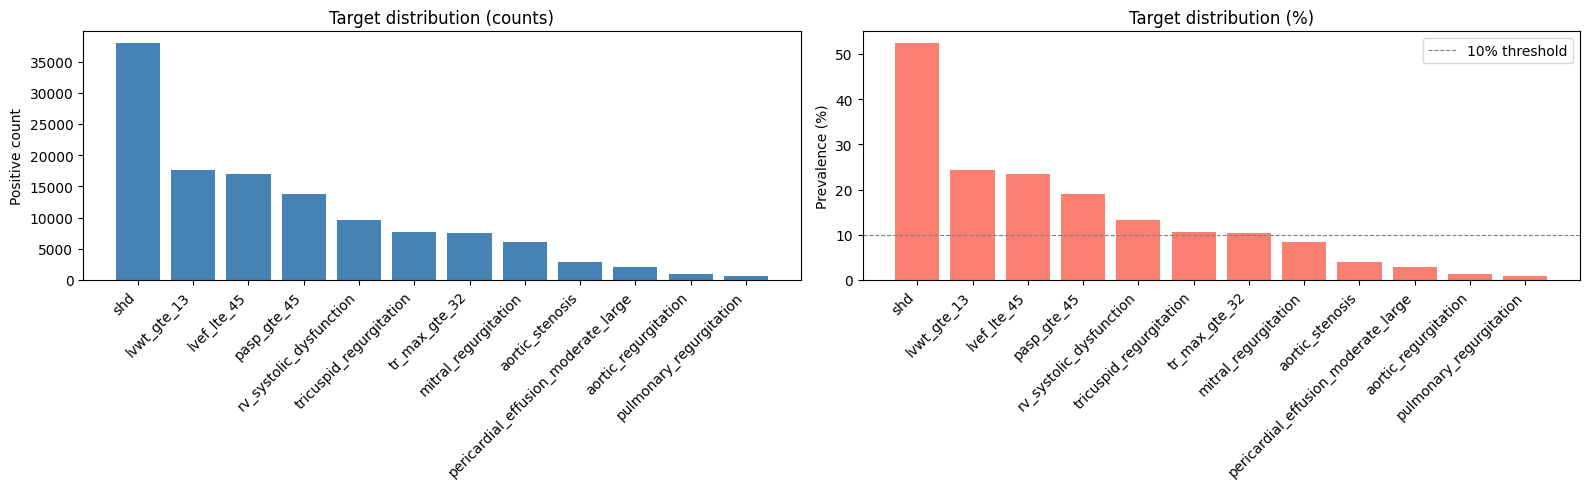

In [42]:
target_counts = df[features["targets"]].sum().sort_values(ascending=False)
target_pct = (target_counts / len(df) * 100)

short_names = [t.replace("_moderate_or_greater_flag", "").replace("_flag", "") for t in target_pct.index]
x = range(len(short_names))

fig, axes = plt.subplots(1, 2, figsize=(16, 5))

axes[0].bar(x, target_counts.values, color="steelblue")
axes[0].set_xticks(x)
axes[0].set_xticklabels(short_names, rotation=45, ha="right")
axes[0].set_ylabel("Positive count")
axes[0].set_title("Target distribution (counts)")

axes[1].bar(x, target_pct.values, color="salmon")
axes[1].set_xticks(x)
axes[1].set_xticklabels(short_names, rotation=45, ha="right")
axes[1].set_ylabel("Prevalence (%)")
axes[1].set_title("Target distribution (%)")
axes[1].axhline(y=10, color="gray", linestyle="--", linewidth=0.8, label="10% threshold")
axes[1].legend()

plt.tight_layout()
plt.show()


Overall counting all SHDs we have around 50 50 1s and 0s. But 5 targets positive values don't even achieve 10% of all observations. It needs to be taken into consideration during modelling process.

Targets to remember about small number of positives:
- mitral_regurgitation
- aortic_stenosis
- pericardial_effusion_moderate_large
- aortic_regurgitation
- pulmonary_regurgitation

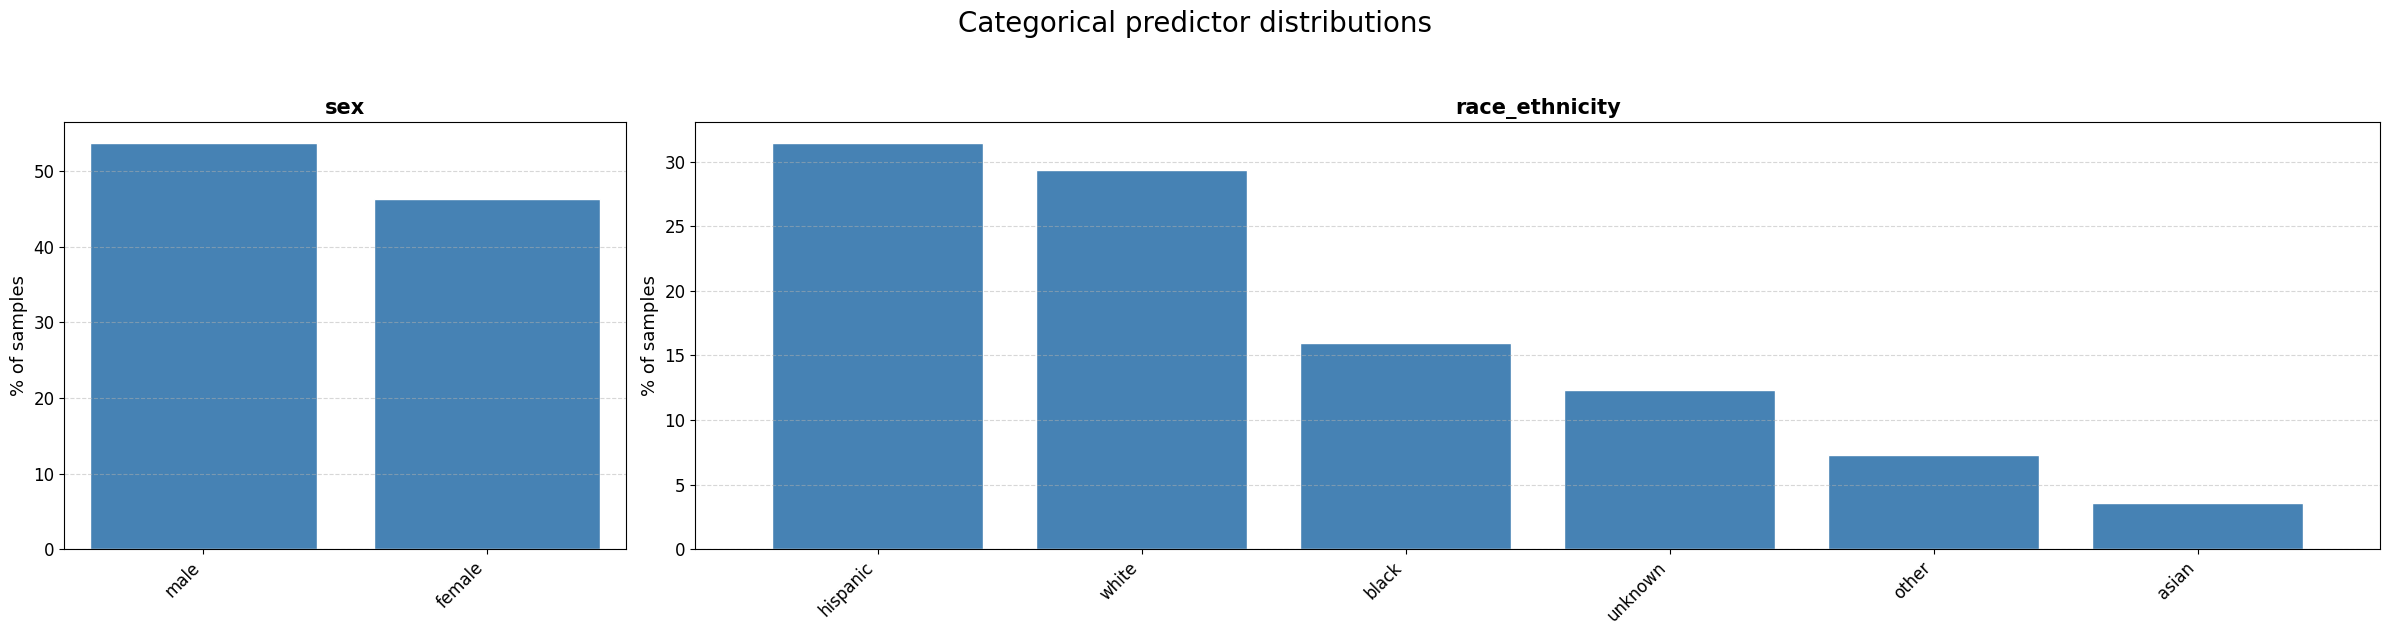

In [45]:
import matplotlib.gridspec as gridspec

cat_cols = features["predictors"]["categorical"]
n_cats = [len(df[col].unique()) for col in cat_cols]

fig = plt.figure(figsize=(sum(n_cats) * 3, 6)) 
gs = gridspec.GridSpec(1, len(cat_cols), width_ratios=n_cats)

for i, col in enumerate(cat_cols):
    ax = fig.add_subplot(gs[i])
    
    counts = df[col].value_counts(dropna=False).sort_values(ascending=False)
    x = range(len(counts))
    
    ax.bar(x, counts.values / len(df) * 100, color="steelblue", edgecolor="white")
    
    ax.set_xticks(x)
    ax.set_xticklabels(counts.index.astype(str), rotation=45, ha="right", fontsize=12)
    
    ax.set_ylabel("% of samples", fontsize=13)
    ax.set_title(col, fontsize=15, fontweight='bold')
    
    ax.tick_params(axis='y', labelsize=12)
    
    ax.grid(axis='y', linestyle='--', alpha=0.5)

plt.suptitle("Categorical predictor distributions", y=1.05, fontsize=20)
plt.tight_layout()
plt.show()

So there's similar fraction of both sexes in the dataset, though there's more men. In the case of ethnicity there's under represantation of asian ethnicity and other.

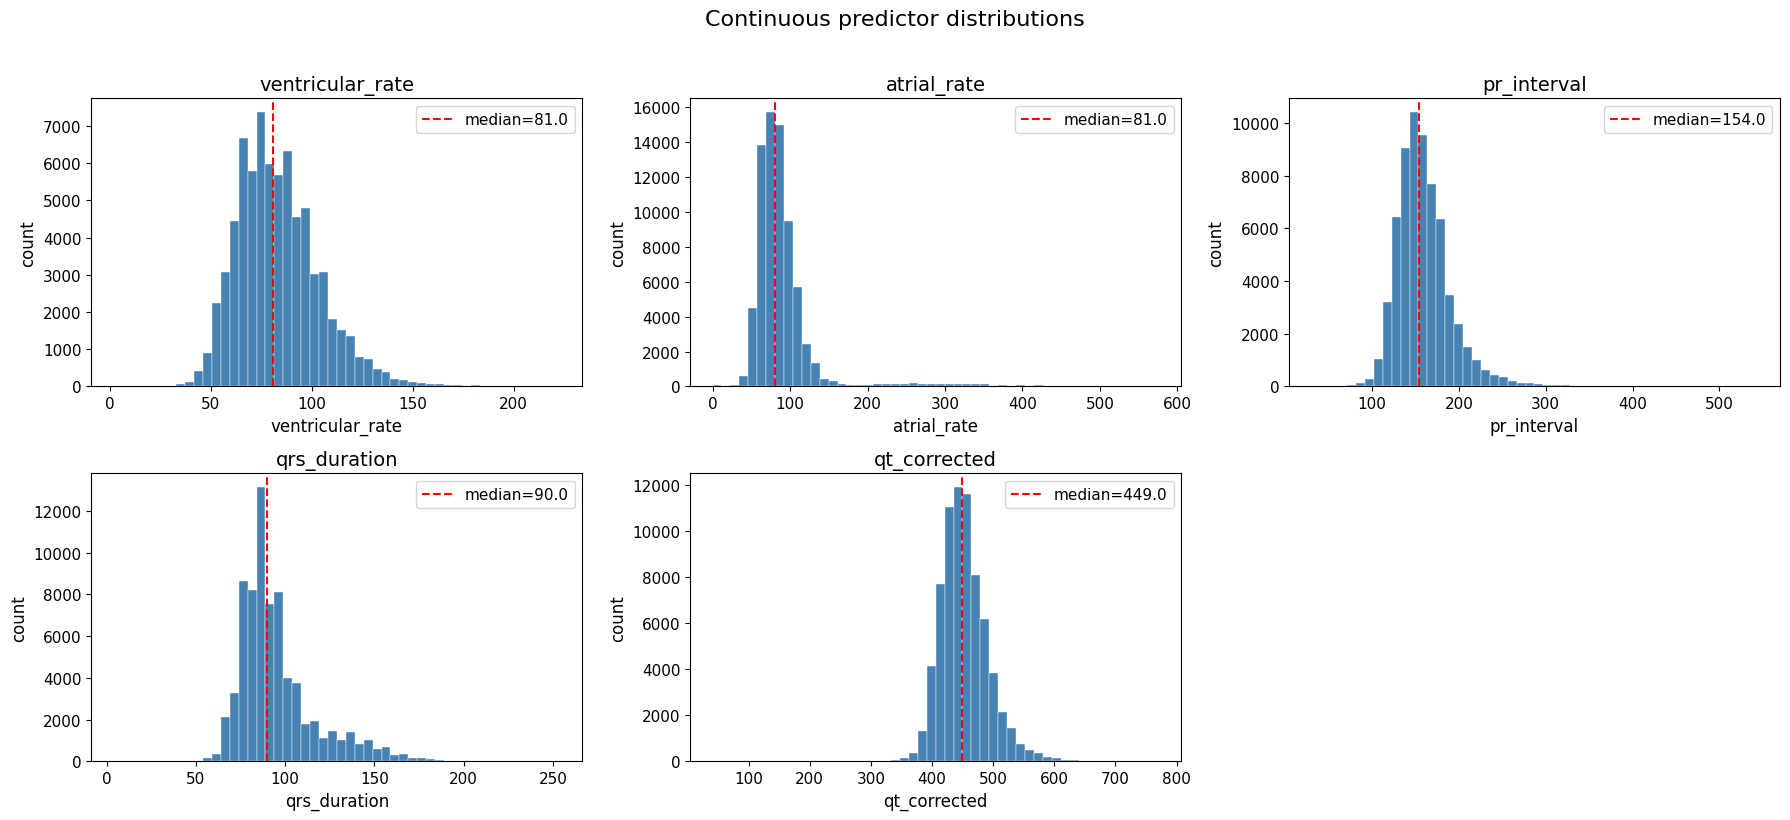

In [17]:
# univariate distributions continuous predictors
cont_cols = features["predictors"]["continuous"]
ncols = 3
nrows = -(-len(cont_cols) // ncols)

fig, axes = plt.subplots(nrows, ncols, figsize=(6 * ncols, 4 * nrows))
axes = axes.flatten()

for ax, col in zip(axes, cont_cols):
    data = df[col].dropna()
    ax.hist(data, bins=50, color="steelblue", edgecolor="white", linewidth=0.3)
    ax.axvline(data.median(), color="red", linestyle="--", linewidth=1.5, label=f"median={data.median():.1f}")
    ax.set_title(col, fontsize=14)
    ax.set_xlabel(col, fontsize=12)
    ax.set_ylabel("count", fontsize=12)
    ax.tick_params(axis="both", labelsize=11)
    ax.legend(fontsize=11)

for ax in axes[len(cont_cols):]:
    ax.set_visible(False)

plt.suptitle("Continuous predictor distributions", fontsize=16, y=1.02)
plt.tight_layout()
plt.show()


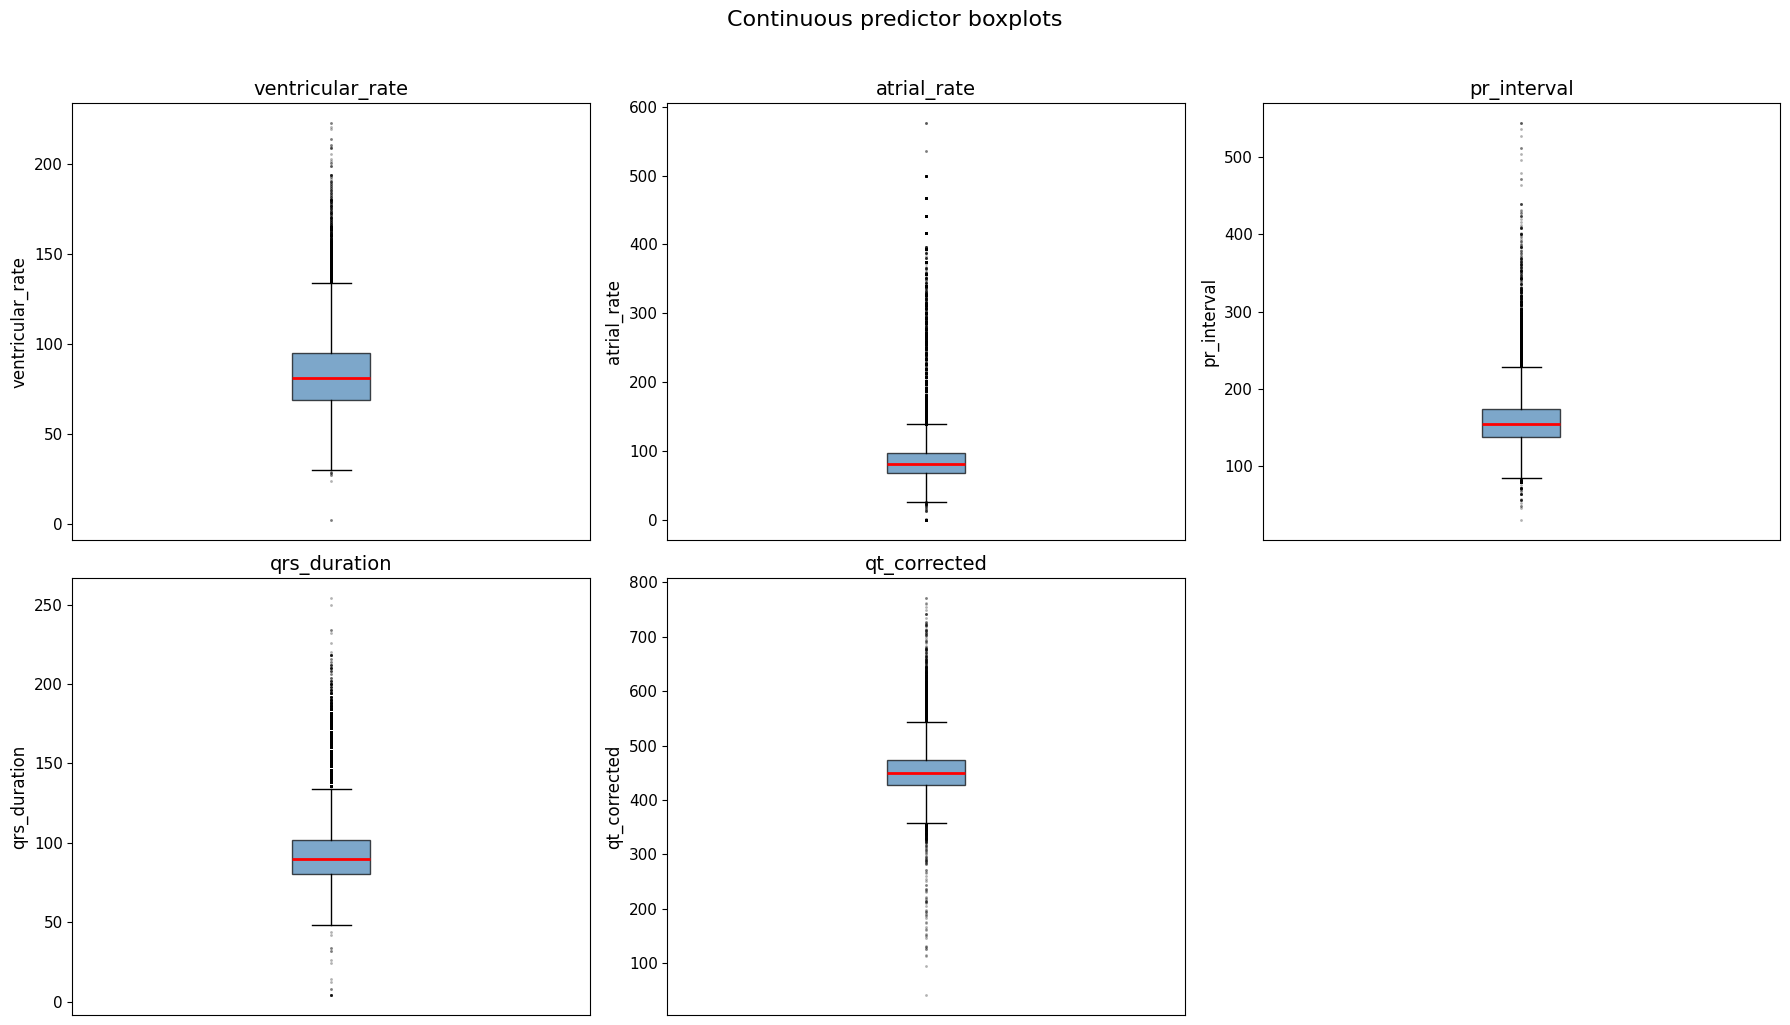

In [18]:
# boxplots for continuous predictors
ncols = 3
nrows = -(-len(cont_cols) // ncols)

fig, axes = plt.subplots(nrows, ncols, figsize=(6 * ncols, 5 * nrows))
axes = axes.flatten()

for ax, col in zip(axes, cont_cols):
    data = df[col].dropna()
    ax.boxplot(data, vert=True, patch_artist=True,
               boxprops=dict(facecolor="steelblue", alpha=0.7),
               medianprops=dict(color="red", linewidth=2),
               flierprops=dict(marker=".", markersize=2, alpha=0.3))
    ax.set_title(col, fontsize=14)
    ax.set_ylabel(col, fontsize=12)
    ax.tick_params(axis="both", labelsize=11)
    ax.set_xticks([])

for ax in axes[len(cont_cols):]:
    ax.set_visible(False)

plt.suptitle("Continuous predictor boxplots", fontsize=16, y=1.02)
plt.tight_layout()
plt.show()


Ventricular Rate (median: 81.0 bpm): This distribution is slightly right-skewed. Most patients fall within the 60-100 bpm range. However, there are instances extending toward 200 bpm.

Atrial Rate (median: 81.0 bpm): While the median is identical to the ventricular rate, suggesting most subjects are in a 1:1 heart rhythm, the distribution has a very long tail reaching up to 600 bpm. So there are more extreme outliers.

PR Interval (median: 154.0 ms): The bulk of the data sits between 120 ms and 200 ms. The distribution is also slightly right-skewed.

QRS Duration (median: 90 ms): The distribution is again right-skewed. Most individuals fall beneath 110. It also has quite a long right tail.

QT Corrected (median: 449.0 ms): The distribution is bell shaped with long tails at both ends.

## Data Quality checks

In [19]:
# age
df['age_at_ecg'].describe()

count    72475.000000
mean        61.269679
std         16.008940
min         18.000000
25%         52.000000
50%         63.000000
75%         73.000000
max         90.000000
Name: age_at_ecg, dtype: float64

all of them seem plausible

In [20]:
# ventricular rate
df['ventricular_rate'].describe()

count    72475.000000
mean        83.379000
std         20.388859
min          2.000000
25%         69.000000
50%         81.000000
75%         95.000000
max        223.000000
Name: ventricular_rate, dtype: float64

max seems to be plausible in extreme case but min looks weird

In [21]:
df['ventricular_rate'].nsmallest(10)

342       2.0
46282     2.0
41876    24.0
37578    27.0
39110    27.0
9814     28.0
17991    28.0
66303    28.0
51180    29.0
2599     30.0
Name: ventricular_rate, dtype: float64

those 2 bpm could be only done in dying patients or are mistakes - either way not really the best to train a model. need to remember about this in preprocessing.

In [22]:
# atrial rate
df['atrial_rate'].describe()

count    72023.000000
mean        89.787151
std         44.007286
min          0.000000
25%         69.000000
50%         81.000000
75%         97.000000
max        576.000000
Name: atrial_rate, dtype: float64

it can exceed 500 in very extreme cases but let's check. also for min 0 is weird

In [23]:
df['atrial_rate'].nlargest(10)

55931    576.0
59103    576.0
65701    576.0
40452    535.0
71010    535.0
4939     500.0
5336     500.0
6636     500.0
9372     500.0
12790    500.0
Name: atrial_rate, dtype: float64

In [24]:
df['atrial_rate'].nsmallest(10)

1032     0.0
1252     0.0
2492     0.0
4682     0.0
5502     0.0
9333     0.0
9450     0.0
9903     0.0
12047    0.0
12816    0.0
Name: atrial_rate, dtype: float64

i read that as long as ventricles are pumping a person can have atrial rate 0 so it's fine

In [25]:
# pr interval
df['pr_interval'].describe()

count    64856.000000
mean       159.665860
std         32.337435
min         30.000000
25%        138.000000
50%        154.000000
75%        174.000000
max        544.000000
Name: pr_interval, dtype: float64

In [26]:
df['pr_interval'].nsmallest(15)

13824    30.0
30530    46.0
42318    48.0
54608    48.0
51192    52.0
20832    56.0
22465    56.0
36693    56.0
38308    56.0
59805    56.0
23714    58.0
4203     64.0
8454     64.0
9784     64.0
13527    64.0
Name: pr_interval, dtype: float64

i read that pr interval almost always stays above 60 ms so these are suspicious. The max values seem fine because I read that there were recorded values even higher.

In [27]:
# qrs duration
df['qrs_duration'].describe()

count    72475.000000
mean        94.809258
std         21.872173
min          4.000000
25%         80.000000
50%         90.000000
75%        102.000000
max        254.000000
Name: qrs_duration, dtype: float64

the max seems valid but lowest values seem like some errors because it physiccally can't be much faster than 50 ms.

In [28]:
df['qrs_duration'].nsmallest(25)

1261      4.0
4501      4.0
6636      4.0
7520      4.0
15806     4.0
22440     4.0
49489     4.0
16981     8.0
23714     8.0
34789    12.0
12348    14.0
40631    24.0
24921    26.0
25417    32.0
45546    32.0
38679    34.0
44765    34.0
33294    42.0
60719    44.0
14383    48.0
38849    48.0
41295    48.0
43997    48.0
4024     50.0
8185     50.0
Name: qrs_duration, dtype: float64

In [29]:
df['qt_corrected'].describe()

count    72474.000000
mean       452.879667
std         40.091749
min         41.000000
25%        427.000000
50%        449.000000
75%        474.000000
max        771.000000
Name: qt_corrected, dtype: float64

the values above 750 and below 300 are quite suspicious

In [30]:
df['qt_corrected'].nsmallest(20)

46282     41.0
34852     95.0
13885    113.0
23714    114.0
10031    125.0
55214    126.0
342      130.0
69401    130.0
65332    132.0
57863    146.0
60474    150.0
68716    152.0
62682    153.0
24921    160.0
40292    162.0
22440    166.0
26547    173.0
70797    176.0
7879     183.0
66007    186.0
Name: qt_corrected, dtype: float64

In [31]:
df['qt_corrected'].nlargest(20)

5827     771.0
33165    771.0
48573    763.0
1771     761.0
67691    755.0
28359    749.0
1041     742.0
15190    742.0
2150     741.0
45247    741.0
66343    734.0
10978    728.0
6196     727.0
23843    725.0
10322    724.0
10829    723.0
10065    722.0
1827     721.0
15518    721.0
5599     720.0
Name: qt_corrected, dtype: float64

I think I need to look at ECGs when I visualize them, but I may get rid of such extreme outliers.

The feratures are not constant or near constant as we see on distribution plots.

## Bivariate analysis with targets

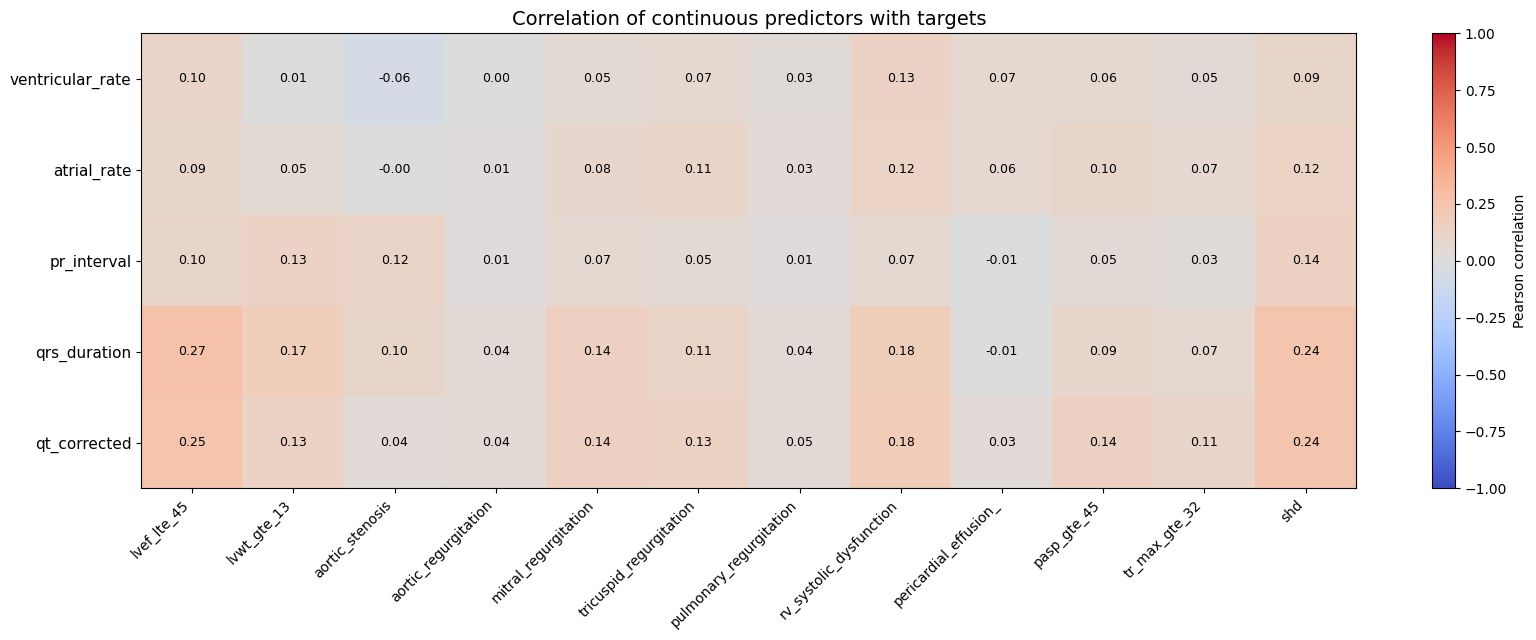

,feature_with_max_abs_corr,max_abs_corr,signed_corr
lvef_lte_45_flag,qrs_duration,0.273343,0.273343
shd_moderate_or_greater_flag,qt_corrected,0.239992,0.239992
rv_systolic_dysfunction_moderate_or_greater_flag,qt_corrected,0.181929,0.181929
lvwt_gte_13_flag,qrs_duration,0.166440,0.166440
mitral_regurgitation_moderate_or_greater_flag,qrs_duration,0.144370,0.144370
pasp_gte_45_flag,qt_corrected,0.136058,0.136058
tricuspid_regurgitation_moderate_or_greater_flag,qt_corrected,0.130353,0.130353
aortic_stenosis_moderate_or_greater_flag,pr_interval,0.116272,0.116272
tr_max_gte_32_flag,qt_corrected,0.109145,0.109145
pericardial_effusion_moderate_large_flag,ventricular_rate,0.069620,0.069620


In [32]:
# continuous predictors vs targets: correlation heatmap
corr_with_targets = (
    df[cont_cols + features["targets"]]
    .corr(numeric_only=True)
    .loc[cont_cols, features["targets"]]
)

fig, ax = plt.subplots(figsize=(1.4 * len(features["targets"]), 1.1 * len(cont_cols) + 1))
im = ax.imshow(corr_with_targets.values, cmap="coolwarm", vmin=-1, vmax=1, aspect="auto")

ax.set_xticks(range(len(features["targets"])))
ax.set_xticklabels(
    [t.replace("_moderate_or_greater_flag", "").replace("_flag", "").replace("moderate_large", "") for t in features["targets"]],
    rotation=45,
    ha="right",
    fontsize=10,
)
ax.set_yticks(range(len(cont_cols)))
ax.set_yticklabels(cont_cols, fontsize=11)
ax.set_title("Correlation of continuous predictors with targets", fontsize=14)

for i in range(corr_with_targets.shape[0]):
    for j in range(corr_with_targets.shape[1]):
        value = corr_with_targets.iloc[i, j]
        ax.text(j, i, f"{value:.2f}", ha="center", va="center", color="black", fontsize=9)

plt.colorbar(im, ax=ax, label="Pearson correlation")
plt.tight_layout()
plt.show()

max_abs_corr_per_target = pd.DataFrame(
    {
        "feature_with_max_abs_corr": corr_with_targets.abs().idxmax(),
        "max_abs_corr": corr_with_targets.abs().max(),
        "signed_corr": corr_with_targets.apply(lambda col: col.loc[col.abs().idxmax()]),
    }
).sort_values("max_abs_corr", ascending=False)

max_abs_corr_per_target


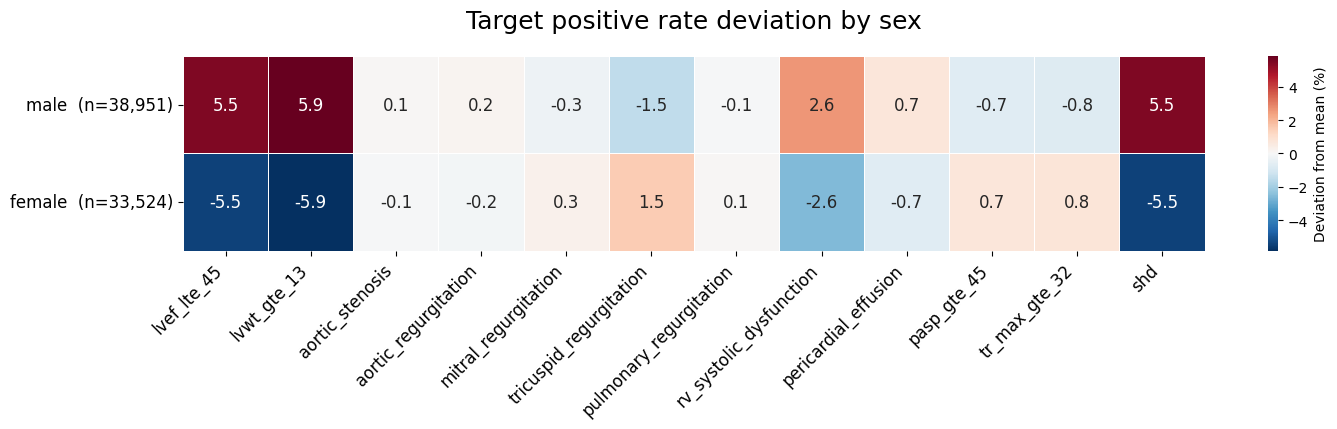

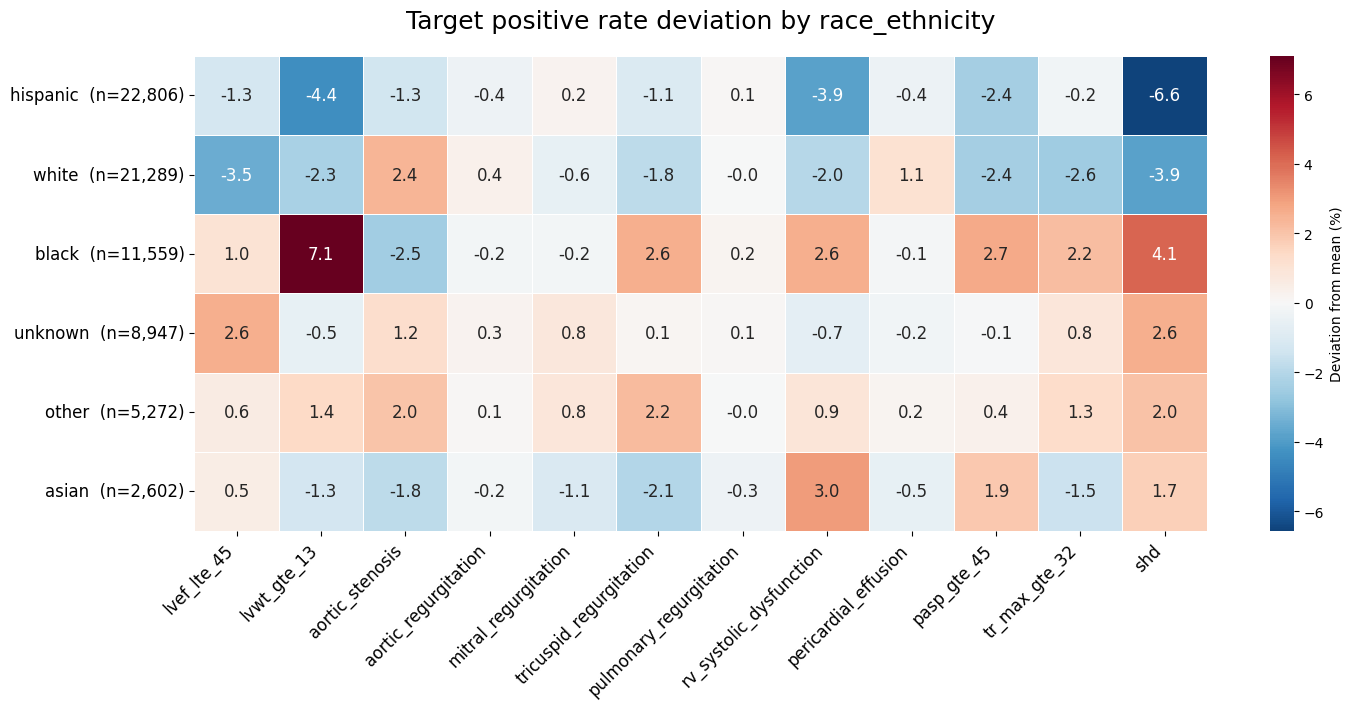

In [47]:
# categorical predictors vs targets: positive rate heatmaps
for col in cat_cols:
    values = df[col].fillna("Missing")
    val_counts = values.value_counts()

    rate_data = {}
    for target in features["targets"]:
        rate_data[target] = df.groupby(values)[target].mean().mul(100)
    
    rate_matrix = pd.DataFrame(rate_data).loc[val_counts.index]

    deviation_matrix = rate_matrix.sub(rate_matrix.mean(), axis=1)

    short_targets = [
        t.replace("_moderate_or_greater_flag", "").replace("_flag", "").replace("_moderate_large", "")
        for t in features["targets"]
    ]
    deviation_matrix.columns = short_targets
    y_labels = [f"{v}  (n={val_counts[v]:,})" for v in deviation_matrix.index]
    deviation_matrix.index = y_labels

    plt.figure(figsize=(0.9 * len(short_targets) + 4, 0.7 * len(deviation_matrix) + 3))
    
    sns.heatmap(
        deviation_matrix, 
        annot=True, 
        fmt=".1f", 
        cmap="RdBu_r",           
        center=0,              
        cbar_kws={'label': 'Deviation from mean (%)'},
        annot_kws={"size": 12}, 
        linewidths=0.7,
        linecolor='white'
    )

    plt.title(f"Target positive rate deviation by {col}", fontsize=18, pad=20)
    plt.xticks(rotation=45, ha="right", fontsize=12)
    plt.yticks(rotation=0, fontsize=12)
    
    plt.tight_layout()
    plt.show()


## Correlation of features

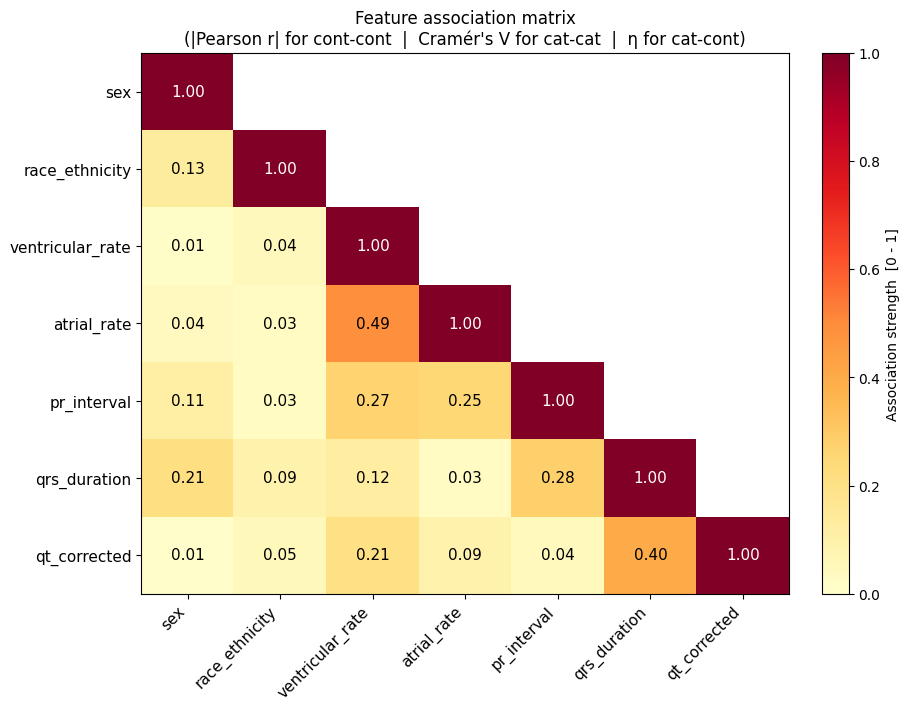

In [34]:
all_predictor_cols = cat_cols + cont_cols


def cramers_v(x, y):
    ct = pd.crosstab(x, y)
    chi2, _, _, _ = chi2_contingency(ct)
    n = ct.values.sum()
    min_dim = min(ct.shape) - 1
    return np.sqrt(chi2 / (n * min_dim)) if min_dim > 0 else 0.0


def correlation_ratio(cat_series, cont_series):
    grand_mean = cont_series.mean()
    ss_between = sum(
        len(g) * (g.mean() - grand_mean) ** 2
        for _, g in cont_series.groupby(cat_series)
    )
    ss_total = ((cont_series - grand_mean) ** 2).sum()
    return np.sqrt(ss_between / ss_total) if ss_total > 0 else 0.0


n = len(all_predictor_cols)
assoc = pd.DataFrame(np.nan, index=all_predictor_cols, columns=all_predictor_cols)

for i, a in enumerate(all_predictor_cols):
    for j, b in enumerate(all_predictor_cols):
        if j > i:
            continue
        if a == b:
            assoc.loc[a, b] = 1.0
        else:
            a_cat, b_cat = a in cat_cols, b in cat_cols
            clean = df[[a, b]].dropna()
            if a_cat and b_cat:
                val = cramers_v(clean[a].fillna("Missing"), clean[b].fillna("Missing"))
            elif not a_cat and not b_cat:
                val = abs(clean.corr().iloc[0, 1])
            else:
                cat_c, cont_c = (a, b) if a_cat else (b, a)
                val = correlation_ratio(clean[cat_c].fillna("Missing"), clean[cont_c])
            assoc.loc[a, b] = val
            assoc.loc[b, a] = val  # mirror

fig, ax = plt.subplots(figsize=(9, 7), constrained_layout=True)

display_vals = np.where(
    np.triu(np.ones((n, n), dtype=bool), k=1),
    np.nan,
    assoc.values.astype(float),
)
im = ax.imshow(display_vals, cmap="YlOrRd", vmin=0, vmax=1, aspect="auto")

ax.set_xticks(range(n))
ax.set_xticklabels(all_predictor_cols, rotation=45, ha="right", fontsize=11)
ax.set_yticks(range(n))
ax.set_yticklabels(all_predictor_cols, fontsize=11)
ax.set_title(
    "Feature association matrix\n"
    "(|Pearson r| for cont-cont  |  Cramér's V for cat-cat  |  η for cat-cont)",
    fontsize=12,
)

for i in range(n):
    for j in range(n):
        if j > i:
            continue
        v = assoc.iloc[i, j]
        txt_color = "white" if v > 0.6 else "black"
        ax.text(j, i, f"{v:.2f}", ha="center", va="center", fontsize=11, color=txt_color)

plt.colorbar(im, ax=ax, label="Association strength  [0 - 1]")
plt.show()


The highest correlation - between atrai rate and ventricular rate - is due to how heart works, so it's better not to remove them.